# Japan — Full Piotroski F-Score Study

The proposal's complete loop on **real data**: point-in-time universe →
high-B/M value subset → 9-signal F-Score → fixed-basket selection (F-Score vs
value / market-cap / liquidity-matched / random Monte-Carlo) → EW / GMV /
sector-capped GMV on RMT-cleaned covariances, plus a dollar-neutral
long-short book (long top-k scores, short bottom-k) where shorting is
available → annual-rebalance backtest →
placement in the random distribution → investable benchmarks → Fama-French
three-factor regression.

**Data & scope.** Yahoo Finance serves ~5 annual statement periods per name, which supports July-1 formations in **2023 and 2024** only — 2025 is excluded because its holding year would run past the sample and be truncated. Report dates are fiscal period ends; the reporting lag is 3 months — the statutory deadline for the securities report (yukashoken hokokusho), so a March fiscal year is public by end-June, just before formation. No free source provides 2000-2025 Japanese fundamentals (J-Quants free tier is 2 years; EDINET XBRL starts 2008 and needs the Japanese-GAAP taxonomy); extending Japan to the proposal window requires a licensed source (J-Quants paid tier / Refinitiv), which plugs into the same canonical schemas. Universe membership is current Nikkei 225 members — a survivorship caveat documented in `src/fscore/data/universe.py`.

Run `python scripts/fetch_us_japan.py`
once before this notebook (builds the git-ignored cache under `data/`).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.plotting import setup_plots, save_fig
from fscore.data.yahoo import load_cached
from fscore.pipeline import run_study
from fscore.evaluation import (metrics, benchmark_returns, fetch_ff_factors,
                               factor_regression, to_usd)

setup_plots()      # study-wide figure defaults; every saved chart is 300 dpi
RESULTS_FIG = ROOT / "results" / "figures"
MARKET = "japan"
YEARS = [2023, 2024]
LAG_MONTHS = 3  # report_date = fiscal period end (no filing dates on Yahoo)
END_CAP = None   # every holding year is complete; nothing is truncated
fund, prices, sectors, bench = load_cached(MARKET, ROOT / "data")
membership = None
print(f"fundamentals: {fund.ticker.nunique()} tickers, "
      f"FY{fund.fiscal_year.min()}–FY{fund.fiscal_year.max()}")
print(f"prices: {prices.ticker.nunique()} tickers, "
      f"{prices.date.min():%Y-%m-%d} → {prices.date.max():%Y-%m-%d}")
fund.groupby("fiscal_year").size().rename("statements")

fundamentals: 223 tickers, FY2021–FY2025
prices: 236 tickers, 2002-01-01 → 2026-08-07


fiscal_year
2021    133
2022    221
2023    223
2024    223
2025    205
Name: statements, dtype: int64

### 1. Run the multi-year study

Per formation year: universe = top-150 names by median dollar volume with
continuous listing and complete, published statements; value subset = top 40%
by B/M (~60 names); baskets of 30; 1,000 random baskets under EW (300 pushed
through the GMV / sector-GMV pipeline).

**Data discarded before any test.** A firm-year is scored
only when all nine signals are computable from the fiscal T-1 and T-2
statements; partial scores are dropped rather than summed over whatever is
available (an incomplete score is not a low score). The per-formation count
is `dropped_incomplete_signals` in the diagnostics below.

In [2]:
study = run_study(MARKET, fund, prices, sectors, YEARS,
                  n_mc=1000, n_mc_opt=300, lag_months=LAG_MONTHS,
                  membership=membership, end_cap=END_CAP, seed=42,
                  detone=False)   # RMT denoise only; see section 4b
diag = pd.DataFrame([{"year": yr.year, **yr.diagnostics} for yr in study.yearly])
diag.set_index("year")

,universe,value_set,scored,dropped_incomplete_signals,tie_break_slots,cov_est_days,delisted_in_holding_year,k,fscore_mean,fscore_basket_min
year,,,,,,,,,,
2023,118,47,9,115,1,733,0,9,6.444444,3
2024,150,60,60,21,2,733,0,30,6.166667,6


### 2. F-Score distribution within the value universe, per formation

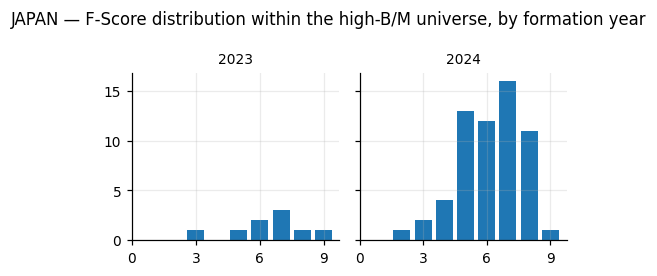

,2023,2024
count,9.00,60.00
mean,6.44,6.17
std,1.74,1.49
min,3.00,2.00
25%,6.00,5.00
50%,7.00,6.00
75%,7.00,7.00
max,9.00,9.00


In [3]:
ncol = min(5, len(YEARS))
nrow = -(-len(YEARS) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(2.3 * ncol, 2.5 * nrow),
                         sharey=True, squeeze=False)
for ax, yr in zip(axes.flat, study.yearly):
    counts = yr.scored.fscore.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{yr.year}", fontsize=9); ax.set_xticks(range(0, 10, 3))
for ax in axes.flat[len(study.yearly):]:
    ax.axis("off")
fig.suptitle(f"{MARKET.upper()} — F-Score distribution within the high-B/M universe, by formation year")
plt.tight_layout(); save_fig(f"{MARKET}_fscore_distribution", directory=RESULTS_FIG); plt.show()

pd.DataFrame({yr.year: yr.scored.fscore.describe() for yr in study.yearly}).round(2)

### 3. Chained track record vs investable benchmarks

1306.T is JPY like the portfolios; EWJV is USD, so its row mixes in currency effects and is indicative only.

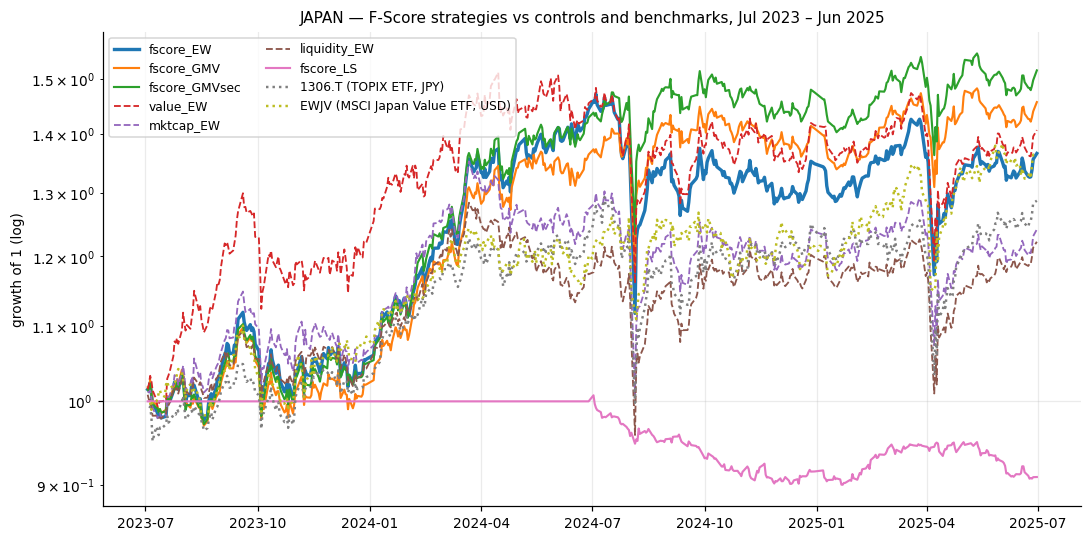

In [4]:
BENCH = {"1306.T (TOPIX ETF, JPY)": "1306.T",
         "EWJV (MSCI Japan Value ETF, USD)": "EWJV"}
start, end = study.daily.index.min(), study.daily.index.max()
bench_rets = {name: benchmark_returns(bench, tk, start, end)
              for name, tk in BENCH.items()}

nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(10, 5))
# solid for the F-Score variants, dashed for the controls; a strategy not
# named here still plots, so adding one never breaks the figure
styles = {"fscore_EW": ("-", 2.2), "fscore_GMV": ("-", 1.4), "fscore_GMVsec": ("-", 1.4),
          "fscore_LS": ("-", 1.4),
          "value_EW": ("--", 1.2), "mktcap_EW": ("--", 1.2), "liquidity_EW": ("--", 1.2)}
for s in study.daily.columns:
    ls, lw = styles.get(s, ("-" if s.startswith("fscore") else "-.", 1.2))
    ax.plot(nav.index, nav[s], ls, lw=lw, label=s)
for name, r in bench_rets.items():
    ax.plot((1 + r).cumprod(), ":", lw=1.6, label=name)
ax.set_ylabel("growth of 1 (log)"); ax.set_yscale("log")
ax.set_title(f"{MARKET.upper()} — F-Score strategies vs controls and benchmarks, "
             f"{start:%b %Y} – {end:%b %Y}")
ax.legend(fontsize=8, ncol=2); plt.tight_layout()
save_fig(f"{MARKET}_nav_vs_benchmarks", directory=RESULTS_FIG); plt.show()

In [5]:
tbl = study.summary()      # gross first; costs follow separately
for name, r in bench_rets.items():
    tbl.loc[name] = metrics(r)   # benchmarks are buy-and-hold: no turnover
tbl[["ann_return", "ann_vol", "sharpe", "max_drawdown",
     "nominal_k", "effective_n"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,nominal_k,effective_n
fscore_EW,0.175,0.235,0.747,-0.241,9.0,19.500
fscore_GMV,0.215,0.202,1.067,-0.159,9.0,6.486
fscore_GMVsec,0.240,0.205,1.170,-0.163,9.0,7.790
value_EW,0.193,0.246,0.784,-0.233,9.0,19.500
mktcap_EW,0.118,0.227,0.521,-0.255,9.0,19.500
liquidity_EW,0.110,0.210,0.520,-0.253,9.0,19.500
fscore_LS,-0.094,0.066,-1.430,-0.106,NaN,60.000
"1306.T (TOPIX ETF, JPY)",0.140,0.214,0.651,-0.228,NaN,NaN
"EWJV (MSCI Japan Value ETF, USD)",0.168,0.184,0.912,-0.146,NaN,NaN


`nominal_k` is the basket size, `effective_n` is 1/Σw² —
an optimised or sector-capped book concentrates, so the two are not the same
number of holdings. Turnover and the net-of-cost sensitivity follow below.

In [6]:
tbl[["turnover", "cost_drag",
     "net_ann_return", "net_sharpe"]].round(4)

,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.9667,0.0039,0.1713,0.7301
fscore_GMV,1.0000,0.0040,0.2111,1.0468
fscore_GMVsec,1.0000,0.0040,0.2365,1.1509
value_EW,0.8000,0.0032,0.1900,0.7713
mktcap_EW,0.7667,0.0031,0.1154,0.5077
liquidity_EW,0.9333,0.0037,0.1058,0.5026
fscore_LS,0.0000,0.0100,-0.1040,-1.5821
"1306.T (TOPIX ETF, JPY)",NaN,NaN,NaN,NaN
"EWJV (MSCI Japan Value ETF, USD)",NaN,NaN,NaN,NaN


### 4. Statistical control — placement in the Monte-Carlo random distribution

Same universe, same basket size, same construction pipeline; the only
difference is *which* 30 names. Percentile = share of random baskets the
F-Score portfolio beats; the p-value is one-sided and judged at the study's
single significance level, **5%** (`significant` column). No 1% or 10% tier
is used, so p = 0.06 counts as not significant.

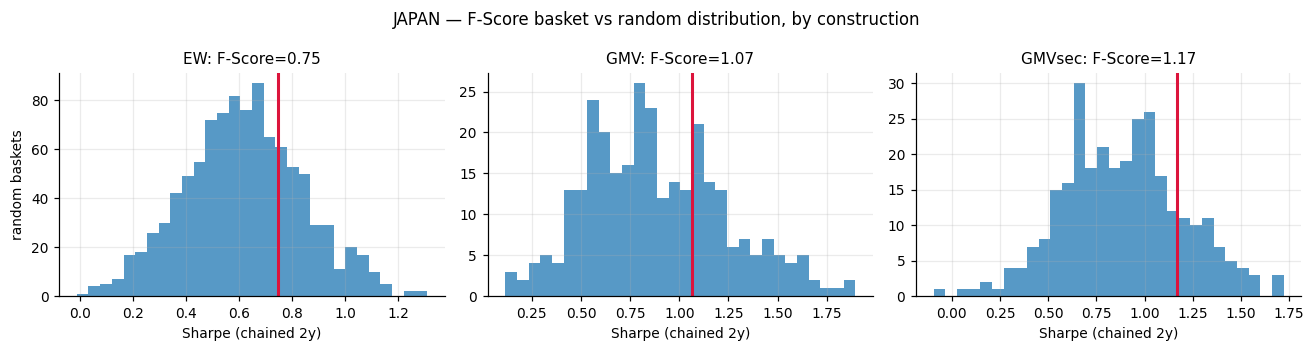

fscore random_mean random_std percentile  \
fscore_EW     ann_return    0.175199    0.140219    0.05139      0.759   
              sharpe        0.746569    0.617636   0.222926      0.724   
              max_drawdown -0.241095   -0.231654   0.014871      0.225   
fscore_GMV    ann_return    0.215143    0.170145   0.069296   0.733333   
              sharpe        1.066673    0.883539   0.352476   0.693333   
              max_drawdown -0.159433   -0.163331   0.027707   0.483333   
fscore_GMVsec ann_return    0.240495    0.170916   0.060936   0.873333   
              sharpe         1.17037    0.888252   0.314062   0.816667   
              max_drawdown -0.163287   -0.164389    0.01971   0.483333   

                             p_value significant n_draws  
fscore_EW     ann_return       0.241       False    1000  
              sharpe           0.276       False    1000  
              max_drawdown     0.775       False    1000  
fscore_GMV    ann_return    0.266667       False     300  
              sharpe        0.306667       False     300  
              max_drawdown  0.516667       False     300  
fscore_GMVsec ann_return    0.126667       False     300  
              sharpe        0.183333       False     300  
              max_drawdown  0.516667       False     300

In [7]:
pairs = [("EW", "fscore_EW"), ("GMV", "fscore_GMV"), ("GMVsec", "fscore_GMVsec")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=False)
for ax, (how, strat) in zip(axes, pairs):
    sharpes = study.mc_summary(how)["sharpe"].dropna()
    fs = metrics(study.daily[strat].dropna())["sharpe"]
    ax.hist(sharpes, bins=30, alpha=0.75)
    ax.axvline(fs, color="crimson", lw=2)
    ax.set_title(f"{how}: F-Score={fs:.2f}", fontsize=10)
    ax.set_xlabel(f"Sharpe (chained {len(YEARS)}y)")
axes[0].set_ylabel("random baskets")
fig.suptitle(f"{MARKET.upper()} — F-Score basket vs random distribution, by construction")
plt.tight_layout(); save_fig(f"{MARKET}_mc_placement", directory=RESULTS_FIG); plt.show()

placements = pd.concat({strat: study.placement(strat, how) for how, strat in pairs})
placements.round(3)

### 5. Turnover and implied trading cost

One-way turnover per rebalance, computed on each strategy's actual weights
(so GMV pays for weight drift, not just for name changes); cost drag =
2 x turnover x 20 bp per side, already applied in the `net_*` columns above.
For reference, the random control is redrawn every year and turns over
roughly `1 - k/|universe|`, i.e. in the same range as the F-Score basket.

In [8]:
to = study.turnover_table()
to.loc["mean"] = to.mean()
cost = (2 * to.loc["mean"] * 0.0020).rename("annual cost drag")
pd.concat([to.round(3).T, cost.round(4)], axis=1)

,2024,mean,annual cost drag
fscore_EW,0.967,0.967,0.0039
fscore_GMV,1.000,1.000,0.0040
fscore_GMVsec,1.000,1.000,0.0040
value_EW,0.800,0.800,0.0032
mktcap_EW,0.767,0.767,0.0031
liquidity_EW,0.933,0.933,0.0037


### 6. Does alpha survive the factor exposures?

Daily excess returns regressed on the Fama-French three factors (market,
size, value) with Newey-West standard errors. The `alpha_significant` column
is the verdict at the study's single level, 5%. Japan portfolio returns are converted to USD to match the USD-denominated Japan factor set.

In [9]:
ff = fetch_ff_factors("japan")
# Ken French Japan factors are USD-denominated -> convert JPY returns to USD
fx = bench[bench.ticker == "JPY=X"].set_index("date")["adj_close"]
series = {s: to_usd(study.daily[s].dropna(), fx)
          for s in ["fscore_EW", "fscore_GMV", "value_EW"]}
reg = pd.DataFrame({s: factor_regression(r, ff) for s, r in series.items()}).T
reg.round(4)

,alpha_daily,alpha_annual,alpha_tstat,alpha_pvalue,alpha_significant,alpha,beta_mkt,beta_smb,beta_hml,r2,n_obs
fscore_EW,0.000156,0.03925,0.486168,0.626848,False,0.05,0.716809,0.136952,0.133797,0.539484,486
fscore_GMV,0.000403,0.101585,1.121083,0.262252,False,0.05,0.569865,0.240517,0.009412,0.390506,486
value_EW,0.000054,0.013624,0.154588,0.877146,False,0.05,0.70908,0.21442,0.441642,0.514094,486


In [10]:
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
tbl.to_csv(RESULTS / f"{MARKET}_summary.csv")
placements.to_csv(RESULTS / f"{MARKET}_mc_placement.csv")
to.to_csv(RESULTS / f"{MARKET}_turnover.csv")
reg.to_csv(RESULTS / f"{MARKET}_factor_regression.csv")
diag.to_csv(RESULTS / f"{MARKET}_diagnostics.csv", index=False)
print("saved to", RESULTS)

saved to C:\Users\miked\OneDrive\Desktop\Career\WQU\Cap Project\fscore_capstone\results


### 7. Reading the results

*(filled in after execution)*